# Unit 5 - Data Preparation (BBBC039)

Prepare the **BBBC039** dataset for pix2pixHD training: **binary mask → fluorescence image**.

Steps:
1. Download images (TIFF, 16-bit) and masks (PNG, instance-encoded)
2. Binarize masks: any instance ID > 0 → foreground
3. Convert 16-bit fluorescence to 8-bit RGB
4. Resize to **512×512**
5. Split **160 train / 40 test**
6. Arrange in pix2pixHD format (`train_A`, `train_B`, `test_A`, `test_B`)

We use `--label_nc 0` so pix2pixHD treats the mask as a raw RGB input rather than a semantic label map.

In [1]:
import os, urllib.request, zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

print("Libraries ready")

Libraries ready


## 1. Download

BBBC039 — fluorescence microscopy images of U2OS cell nuclei with instance segmentation masks.

In [2]:
data_dir = "data_download"
os.makedirs(data_dir, exist_ok=True)

urls = {
    "images.zip": "https://data.broadinstitute.org/bbbc/BBBC039/images.zip",
    "masks.zip": "https://data.broadinstitute.org/bbbc/BBBC039/masks.zip",
}

for fname, url in urls.items():
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
        print("  done.")
    else:
        print(f"{fname} already present.")

  done.
  done.


## 2. Extract & inspect

In [3]:
for fname in ["images.zip", "masks.zip"]:
    fpath = os.path.join(data_dir, fname)
    with zipfile.ZipFile(fpath, 'r') as z:
        z.extractall(data_dir)

img_files = sorted([f for f in os.listdir(os.path.join(data_dir, "images")) if f.endswith(".tif")])
mask_files = sorted([f for f in os.listdir(os.path.join(data_dir, "masks")) if f.endswith(".png") and not f.startswith("._")])
print(f"Images: {len(img_files)}, Masks: {len(mask_files)}")

Images: 200, Masks: 200


## 3. Raw sample

Images are 696×520, 16-bit grayscale TIFF.
Masks are RGBA PNG; instance IDs live in the **red channel** (0 = background).

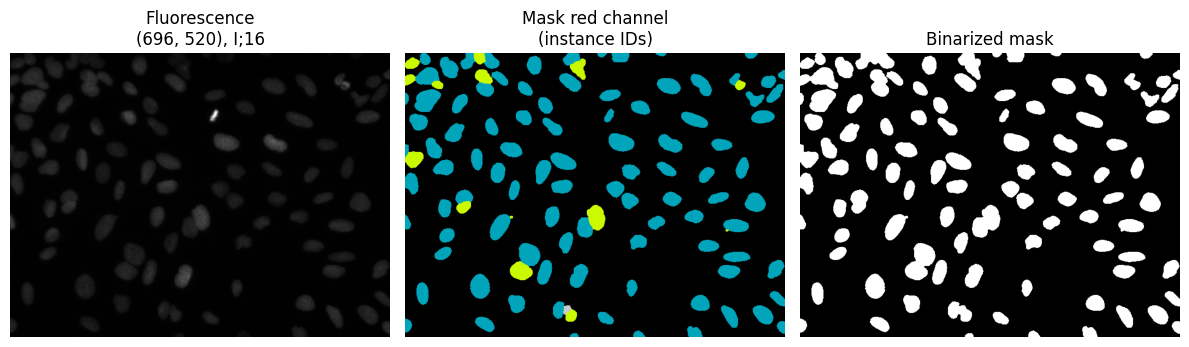

In [4]:
sample = img_files[0]
base = os.path.splitext(sample)[0]
img = Image.open(os.path.join(data_dir, "images", sample))
mask = Image.open(os.path.join(data_dir, "masks", base + ".png"))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.array(img), cmap="gray")
ax[0].set_title(f"Fluorescence\n{img.size}, {img.mode}")
ax[1].imshow(np.array(mask)[:,:,0], cmap="nipy_spectral")
ax[1].set_title("Mask red channel\n(instance IDs)")
ax[2].imshow((np.array(mask)[:,:,0] > 0).astype(np.uint8), cmap="gray")
ax[2].set_title("Binarized mask")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

img on the left is the OG image; binarized mask: foreground value of 1, background value 0

## 4. Process & save in pix2pixHD format

* **Mask** → binarize, convert to RGB, resize 512×512 (nearest)
* **Image** → min-max normalize 16→8-bit, convert to RGB, resize 512×512 (bilinear)
* Directory layout for `--label_nc 0`:
```
datasets/bbbc039/
├── train_A/   # masks
├── train_B/   # fluorescence
├── test_A/
└── test_B/
```
Files in `A` and `B` share the **same basename** so sorting pairs them correctly.

In [5]:
out_root = "datasets/bbbc039"
for split in ["train", "test"]:
    for sub in ["A", "B"]:
        os.makedirs(os.path.join(out_root, f"{split}_{sub}"), exist_ok=True)

# Match by basename
base_to_img = {os.path.splitext(f)[0]: f for f in img_files}
base_to_mask = {os.path.splitext(f)[0]: f for f in mask_files}
common = sorted(set(base_to_img.keys()) & set(base_to_mask.keys()))
print(f"Matched pairs: {len(common)}")

random.seed(42)
random.shuffle(common)
train = common[:160]
test = common[160:]
print(f"Train: {len(train)}, Test: {len(test)}")

TARGET = (512, 512)

def process_and_save(base, split):
    # Image: 16-bit → 8-bit RGB
    img = Image.open(os.path.join(data_dir, "images", base_to_img[base]))
    arr = np.array(img).astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    arr = (arr * 255).astype(np.uint8)
    img_rgb = Image.fromarray(arr).convert("RGB")
    img_rgb = img_rgb.resize(TARGET, Image.BILINEAR)

    # Mask: instance → binary → RGB
    mask = Image.open(os.path.join(data_dir, "masks", base_to_mask[base]))
    r = np.array(mask.split()[0])
    binary = (r > 0).astype(np.uint8) * 255
    mask_rgb = Image.fromarray(binary).convert("RGB")
    mask_rgb = mask_rgb.resize(TARGET, Image.NEAREST)

    img_rgb.save(os.path.join(out_root, f"{split}_B", base + ".png"))
    mask_rgb.save(os.path.join(out_root, f"{split}_A", base + ".png"))

for b in train: process_and_save(b, "train")
for b in test:  process_and_save(b, "test")
print("Saved.")

Matched pairs: 200
Train: 160, Test: 40
Saved.


## 5. Verify output

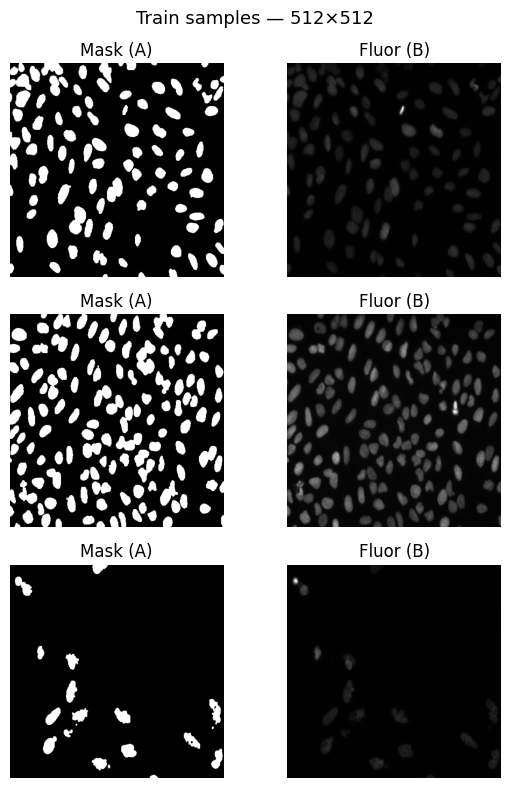

train: A=160, B=160
test: A=40, B=40


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(6, 8))
train_a = sorted(os.listdir(os.path.join(out_root, "train_A")))
for row, fname in enumerate(train_a[:3]):
    a = Image.open(os.path.join(out_root, "train_A", fname))
    b = Image.open(os.path.join(out_root, "train_B", fname))
    axes[row, 0].imshow(a, cmap="gray"); axes[row, 0].set_title("Mask (A)")
    axes[row, 1].imshow(b, cmap="gray"); axes[row, 1].set_title("Fluor (B)")
    for ax in axes[row]: ax.axis("off")
plt.suptitle("Train samples — 512×512", fontsize=13)
plt.tight_layout(); plt.show()

for split in ["train", "test"]:
    na = len(os.listdir(os.path.join(out_root, f"{split}_A")))
    nb = len(os.listdir(os.path.join(out_root, f"{split}_B")))
    print(f"{split}: A={na}, B={nb}")

## Conclusion

The dataset is now in pix2pixHD format at `datasets/bbbc039/`.
Next: use pix2pixHD repo and train (Notebook `01_pix2pixHD_Training`).